In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import Normalize

# -------------------------------
# 1. Load the dataset from parquet
# -------------------------------
# Make sure this path matches your local file location
dataset = pd.read_parquet("dataset/renewables-dataset.parquet")

# %% Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])
#dataset.head()

dataset["ID"] = dataset["ID"].astype(int)

In [49]:
import numpy as np
def find_unique(dataset,country=None):  
    if country is not None: 
        dataset_temp=dataset.iloc[np.where(dataset['country']==country)].copy() 
        IDs=[int(id) for id in dataset_temp["ID"].unique()]
        unique_lats=[lat for lat in dataset_temp["latitude"].unique()]
        unique_lons=[lon for lon in dataset_temp["longitude"].unique()]
        countries=str(country)
    else:
        IDs=[int(id) for id in dataset["ID"].unique()]
        unique_lats=[lat for lat in dataset["latitude"].unique()]
        unique_lons=[lon for lon in dataset["longitude"].unique()]
        countries=[country for country in dataset["country"].unique()]

    return IDs, unique_lats, unique_lons, countries

IDs, unique_lats, unique_lons, countries = find_unique(dataset)

In [50]:
data_mean = np.mean(dataset["demand_MWh"])
data_std = np.std(dataset["demand_MWh"])
dataset["normed_demand"] = (dataset["demand_MWh"] - data_mean)/data_std
print(dataset["normed_demand"])

0          -0.390513
1           1.319916
2          -0.603792
3          -0.628199
4          -0.356073
              ...   
39298171   -0.312694
39298172    3.650167
39298173   -0.628032
39298174   -0.270619
39298175   -0.440186
Name: normed_demand, Length: 39298176, dtype: float64


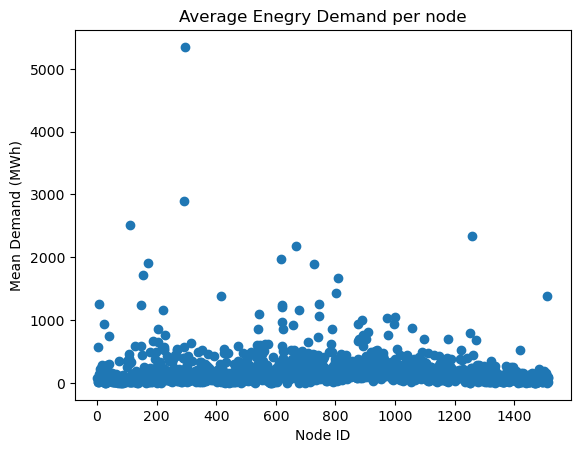

Max value found at ID 296


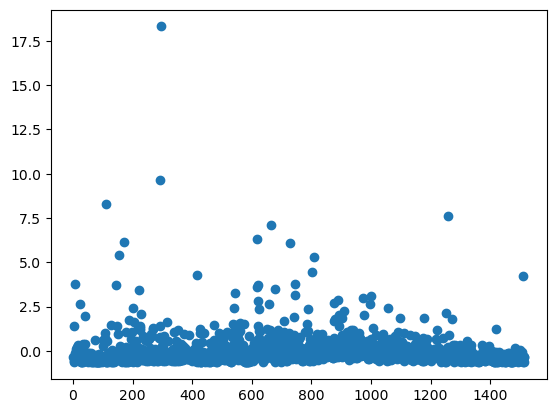

Max value found at ID 296


In [54]:
averages=dataset.groupby('ID')['demand_MWh'].mean()

plt.scatter(IDs, averages)
plt.title('Average Enegry Demand per node')
plt.xlabel('Node ID')
plt.ylabel('Mean Demand (MWh)')
plt.show()

print('Max value found at ID', IDs[np.where(averages==max(averages))[0][0]])

normed_averages=dataset.groupby('ID')['normed_demand'].mean()

plt.scatter(IDs, normed_averages)
plt.show()

print('Max value found at ID', IDs[np.where(normed_averages==max(normed_averages))[0][0]])

In [26]:
averages

ID
1         86.084862
2        578.692428
3         16.039094
4          9.488626
5         88.199071
           ...     
1510     110.827746
1511    1377.862237
1512       7.527012
1513      92.538711
1514      80.161207
Name: demand_MWh, Length: 1494, dtype: float64

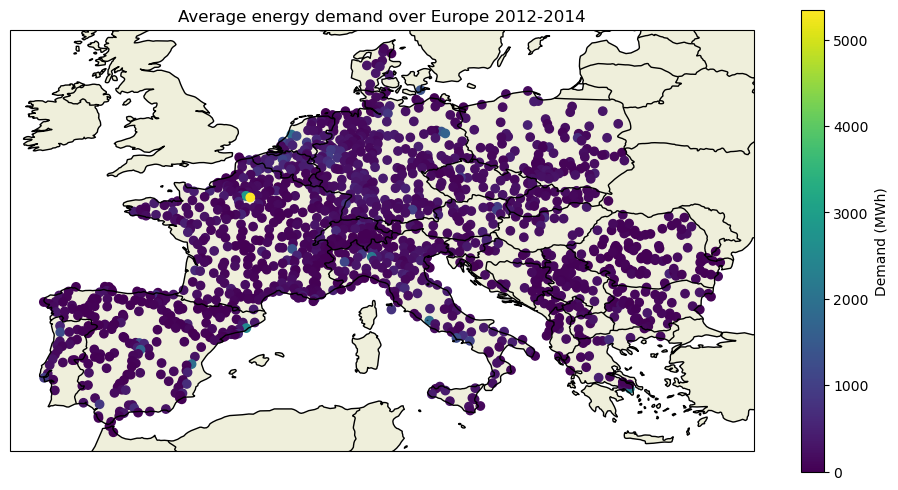

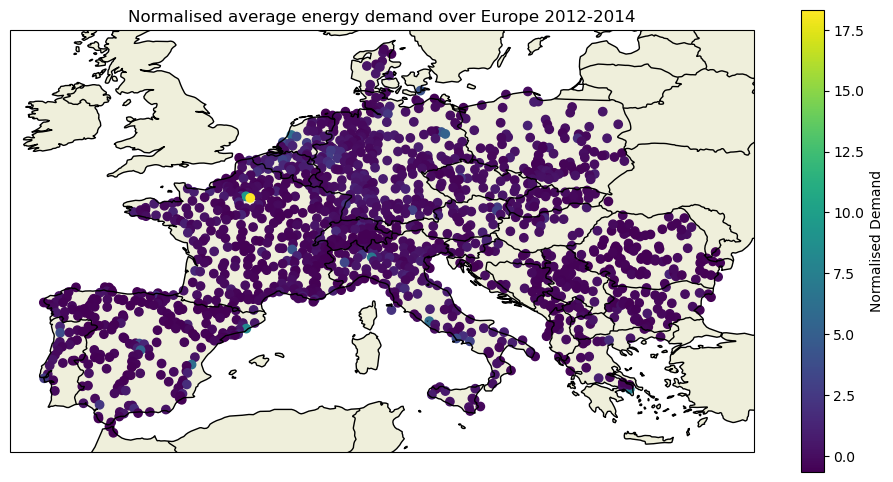

In [27]:
fig, ax = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

ax.coastlines(resolution='50m')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.BORDERS)

im=ax.scatter(unique_lons,unique_lats,c=averages)
plt.colorbar(im, ax=ax, label='Demand (MWh)')
plt.title('Average energy demand over Europe 2012-2014')
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

ax.coastlines(resolution='50m')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.BORDERS)

im=ax.scatter(unique_lons,unique_lats,c=normed_averages)
plt.colorbar(im, ax=ax, label='Normalised Demand')
plt.title('Normalised average energy demand over Europe 2012-2014')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import Normalize

def main():
    dataset = pd.read_parquet("dataset/renewables-dataset.parquet")
    dataset["Time"] = pd.to_datetime(dataset["Time"])
    countries=[country for country in dataset["country"].unique()]
    std=[]

    for c in countries:
        dataset_c=dataset.iloc[np.where(dataset['country']==c)].copy() 
        IDs=[id for id in dataset_c["ID"].unique()]
        unique_lats=[lat for lat in dataset_c["latitude"].unique()]
        unique_lons=[lon for lon in dataset_c["longitude"].unique()]

        averages=dataset_c.groupby('ID')['demand_MWh'].mean()
        std.append(np.std(dataset_c['demand_MWh']))

        fig, ax = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': ccrs.PlateCarree()})
        cmap=plt.cm.cividis
        norm = Normalize(vmin=min(averages), vmax=max(averages))
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

        ax.coastlines(resolution='50m')
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.BORDERS)

        ax.scatter(unique_lons,unique_lats,c=averages)
        plt.colorbar(mappable=sm, ax=ax, label='Demand in MWh')

        plt.title('Energy demand in '+c)

        plt.savefig('energy_demand_'+c+'.jpg')
        plt.show()
    print(countries)
    print(std)

main()

['POR', 'ESP', 'FRA', 'BEL', 'CHE', 'LUX', 'NLD', 'ITA', 'DEU', 'AUT', 'DNK', 'CZE', 'POL', 'HUN', 'SVK', 'SVN', 'HRV', 'GRC', 'ALB', 'MKD', 'BGR', 'MNE', 'BIH', 'SRB', 'ROU']
[297.5060636213725, 299.24638208028654, 378.31811382707866, 260.06398112950495, 153.76798891453745, 87.56147629049124, 474.06818413142537, 311.9696092109856, 219.6280129565144, 226.04528001667688, 364.41730488429704, 160.26565290414112, 124.94050357400981, 148.34285855090462, 70.33579335971177, 147.31198262133108, 89.8958716095301, 500.5659252127234, 68.63437960217605, 74.26111703818357, 83.69695364292298, 42.96231109505701, 57.64400729416444, 68.97835958239628, 71.4377898865253]


In [44]:
max_id=IDs[np.where(averages==max(averages))[0][0]]

max_dataset=dataset.iloc[np.where(dataset['ID']==int(max_id))].copy()

dataset_fr=dataset.iloc[np.where(dataset['country']!='FRA')].copy()


In [45]:
time_average_fr=dataset_fr.groupby('Time')['demand_MWh'].mean()
time_average=dataset.groupby('Time')['demand_MWh'].mean()

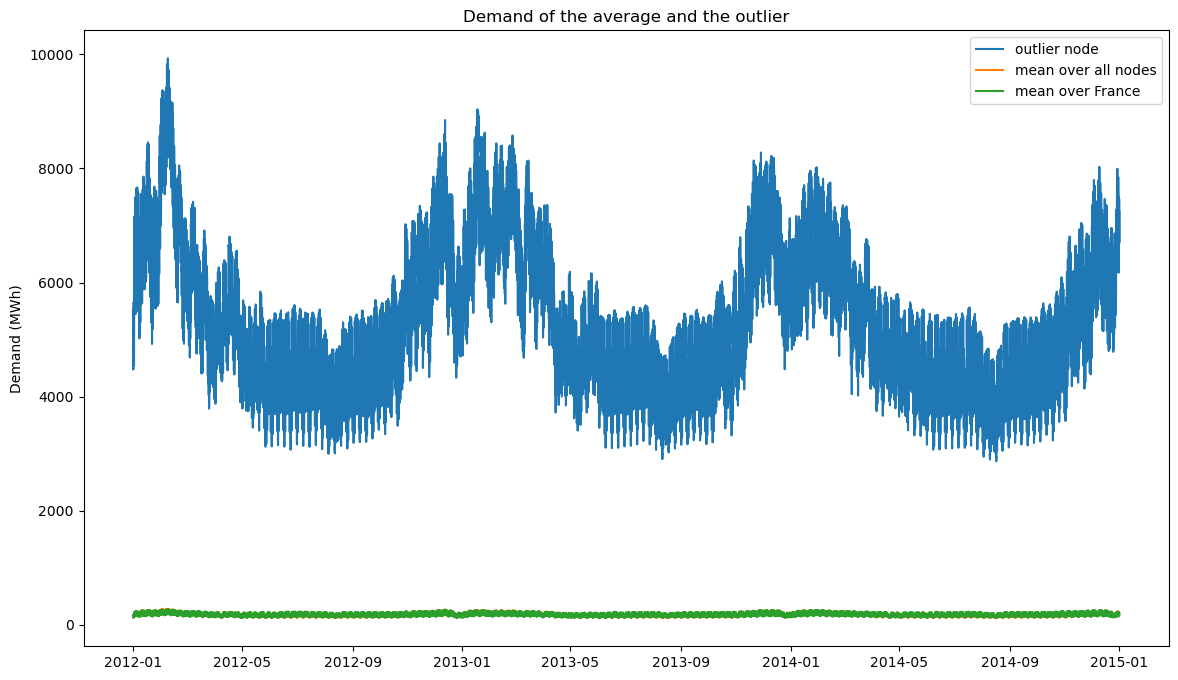

In [ ]:
plt.figure(figsize=[14,8])
plt.plot(max_dataset['Time'],max_dataset['demand_MWh'],label='outlier node')
plt.plot(max_dataset['Time'],time_average,label='mean over all nodes')
plt.plot(max_dataset['Time'],time_average_fr,label='mean over France')
plt.ylabel('Demand (MWh)')
plt.title('Demand of the average and the Parisian outlier')
plt.legend()
plt.show()

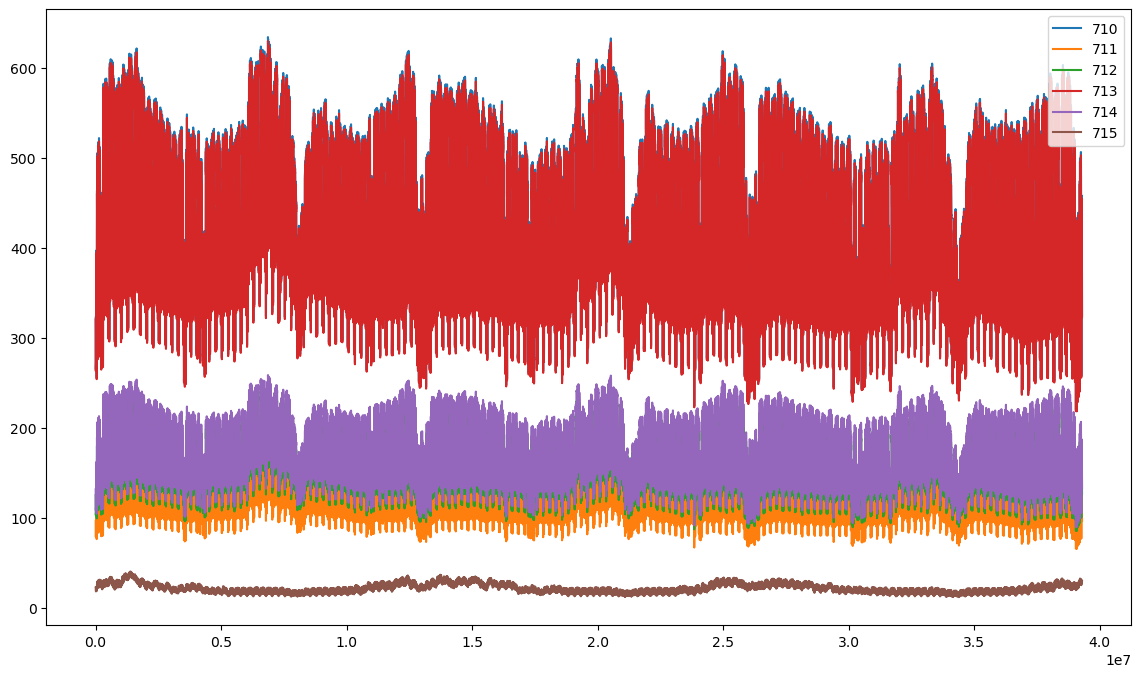

In [103]:
plt.figure(figsize=[14,8])
for i in range(710,716):
    plt.plot(dataset.iloc[np.where(dataset['ID']==str(i))]['demand_MWh'],label=str(i))
plt.legend()
plt.show()

In [17]:
print(dataset.iloc[np.where(dataset['ID']=='715')]['demand_MWh'].mean())
print(dataset.iloc[np.where(dataset['ID']=='715')]['demand_MWh'].std())
print(max(dataset.iloc[np.where(dataset['ID']=='715')]['demand_MWh']))

21.552176851429437
4.897175639847787
40.0132


In [16]:
print(dataset['demand_MWh'].mean())
print(dataset['demand_MWh'].std())
print(max(dataset['demand_MWh']))

185.7546760788287
281.9362797675589
9930.2408


In [18]:
print(dataset.iloc[np.where(dataset['demand_MWh']==max(dataset['demand_MWh']))])

                             Time   ID  demand_MWh  supply_MWh  solar_MWh  \
1389715 2012-02-08 18:00:00+00:00  296   9930.2408   51.879306        0.0   

           wind_MWh  solar_rel_prod  wind_rel_prod  latitude  longitude  \
1389715  103.758611             0.0         0.1907  48.84417   2.420441   

        country  solar_layout_MW  wind_layout_MW  normed_demand  
1389715     FRA         380.5277        544.0934      34.562726  
